In [1]:
from arcgis.gis import GIS
gis = GIS(profile="ent_profile")

Setting `verify_cert` to False is a security risk, use at your own risk.


In [2]:
from arcgis.apps.itemgraph import create_dependency_graph
exb_id = "2af84213b722413f8d4fbd5c0e4e7de2"
exb = gis.content.get(exb_id)
ig = create_dependency_graph(gis = gis, item_list = [exb])
ig.all_items()

[ItemNode(id: 2af84213b722413f8d4fbd5c0e4e7de2, item: myExBApp),
 ItemNode(id: 1545fa4d6242472891a8623b8bc4ba2f, item: myMap),
 ItemNode(id: 7dc6cea0b1764a1f9af2e679f642f0f5),
 ItemNode(id: a571f68af93c45dcb3bbbcf2fe78d32f, item: WorrldAirports),
 ItemNode(id: 095e89a2c792467db0632302623fe930, item: USAStates)]

In [3]:
from arcgis.geoprocessing import import_toolbox
tb = import_toolbox("https://dev0024708.esri.com/server/rest/services/System/PublishingTools/GPServer")

In [4]:
from arcgis.layers import Service

def graph_datastores(item_graph):
    for node in item_graph.all_items():
        item = node.item
        if item == None:
            continue
        if item.type == "Feature Service" and "Map Service" in item.typeKeywords:

            # find Map Service item and it add it to graph
            ms_url = item.url.rstrip("/").split("FeatureServer")[0] + "MapServer"
            ms = Service(ms_url)
            ms_item_id = None
            if ms.properties.get("serviceItemId", None):
                ms_item_id = ms.properties["serviceItemId"]
            else:
                for portal_item in ms.properties.get("portalProperties", {}).get("portalItems"):
                    if portal_item['type'] == "MapServer":
                        ms_item_id = portal_item["itemID"]
                        break
            if ms_item_id:
                ms_item = gis.content.get(ms_item_id)
            else:
                ms_item = None
                ms_item_id = ms_url
            item_graph.add_item(ms_item_id, ms_item)
            item_graph.add_relationship(item.id, ms_item_id)

            # get service datastore info and add it to graph
            service_name = ms_url.split("/")[-2]
            datastore_dict = tb.get_service_datastore_info(service_name, "MapServer")
            for datastore in datastore_dict["datastores"]:
                ds_item = gis.content.get(datastore["id"])
                item_graph.add_item(datastore["id"], ds_item)
                item_graph.add_relationship(ms_item_id, datastore["id"])

            # add datasets to the graph
            for dataset in datastore_dict["datasets"]:
                item_graph.add_item(dataset["datasetName"])
                item_graph.get_node(dataset["datasetName"]).dataset = True
                item_graph.add_relationship(dataset["datastoreID"], dataset["datasetName"])

    return item_graph

In [5]:
ds_graph = graph_datastores(ig)
ds_graph.all_items()

[ItemNode(id: 2af84213b722413f8d4fbd5c0e4e7de2, item: myExBApp),
 ItemNode(id: 1545fa4d6242472891a8623b8bc4ba2f, item: myMap),
 ItemNode(id: 7dc6cea0b1764a1f9af2e679f642f0f5),
 ItemNode(id: a571f68af93c45dcb3bbbcf2fe78d32f, item: WorrldAirports),
 ItemNode(id: 095e89a2c792467db0632302623fe930, item: USAStates),
 ItemNode(id: 3b1644aea0724429ae0dcb5b04197efc, item: WorrldAirports),
 ItemNode(id: 679c8926bd054bd7af3d4e7cce5b1f36, item: ReplicatedAspen),
 ItemNode(id: pgreplicated.map.WorldAirports),
 ItemNode(id: pgreplicated.map.WorldRegion),
 ItemNode(id: f45ee10b5b654898a98c19992b1062d3, item: USAStates),
 ItemNode(id: pgreplicated.map.Publishing_Capitals),
 ItemNode(id: pgreplicated.map.Publishing_Rivers),
 ItemNode(id: pgreplicated.map.Publishing_States)]

In [6]:
import networkx as nx
import matplotlib.pyplot as plt

def generate_labels(item_graph):
    labels = {}
    nodes = item_graph.nodes()
    for node_name in nodes:
        node = item_graph.get_node(node_name)
        if node.item:
            node_label = f"{node.item.title}\n({node.item.type})"
            labels[node_name] = node_label
        elif hasattr(node, 'dataset'):
            node_label = f"{str(node_name)}\n(Dataset)"
            labels[node_name] = node_label
        else:
            labels[node_name] = f"{str(node_name)}\n(Unknown Type)"
    return labels

def plot_graph(item_graph, root):
    # get the labels
    labels = generate_labels(item_graph)
    
    # Create a tree graph (for example, a balanced binary tree)
    tree = nx.bfs_tree(item_graph, root)
    
    # Use graphviz_layout for a clean tree layout
    pos = nx.nx_pydot.graphviz_layout(tree, prog="dot", root = root)
    
    # Draw the graph
    plt.figure(figsize=(10, 6))
    nx.draw(item_graph, pos, with_labels=True, labels=labels, arrows=False, node_size=500, node_color="lightblue", font_size = 7)
    plt.show()

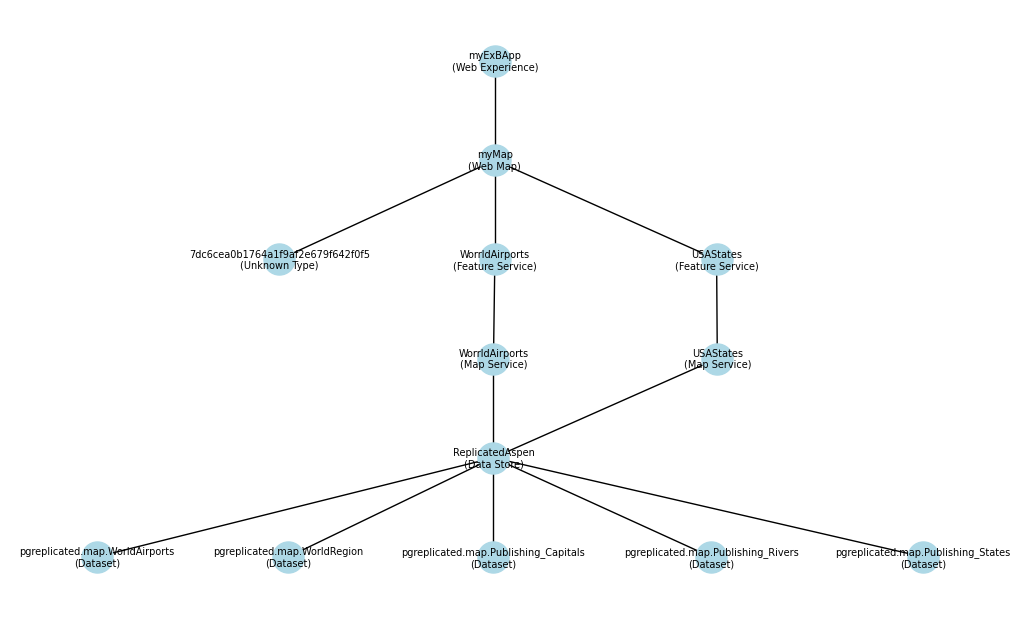

In [7]:
plot_graph(ds_graph, exb_id)